Handling Mixed Variable

In [1]:
import pandas as pd
df=pd.read_csv('train.csv')
df[['Cabin','Ticket','Survived']].sample(10)

,Cabin,Ticket,Survived
338,NaN,7598,1
55,C52,19947,1
561,NaN,349251,0
365,NaN,C 7076,0
310,C54,11767,1
12,NaN,A/5. 2151,0
88,C23 C25 C27,19950,1
513,NaN,PC 17603,1
327,D,28551,1
819,NaN,347088,0


In [2]:
df['Cabin'].isnull().sum()

np.int64(687)

In [3]:
df['Cabin'].unique()

<StringArray>
[          nan,         'C85',        'C123',         'E46',          'G6',
        'C103',         'D56',          'A6', 'C23 C25 C27',         'B78',
 ...
        'B102',         'B69',         'E49',         'C47',         'D28',
         'E17',         'A24',         'C50',         'B42',        'C148']
Length: 148, dtype: str

In [4]:
df['Deck']=df['Cabin'].str[0]


In [5]:
df[['Cabin','Deck']].sample(10)

,Cabin,Deck
799,NaN,NaN
200,NaN,NaN
294,NaN,NaN
397,NaN,NaN
206,NaN,NaN
513,NaN,NaN
674,NaN,NaN
736,NaN,NaN
825,NaN,NaN
401,NaN,NaN


In [6]:
df['Cabin_Number']=df['Cabin'].str[1:]

In [7]:
df['Cabin_count']=df['Cabin'].str.split().str.len()

In [8]:
df[['Cabin','Deck','Cabin_count']].sample(10)

,Cabin,Deck,Cabin_count
348,NaN,NaN,NaN
502,NaN,NaN,NaN
304,NaN,NaN,NaN
432,NaN,NaN,NaN
11,C103,C,1.0
686,NaN,NaN,NaN
360,NaN,NaN,NaN
355,NaN,NaN,NaN
276,NaN,NaN,NaN
420,NaN,NaN,NaN


In [9]:
df['Cabin_Number']=df['Cabin'].str.findall(r'\d+')

In [10]:
df[['Cabin','Ticket','Deck','Cabin_count','Cabin_Number']].head(10)

,Cabin,Ticket,Deck,Cabin_count,Cabin_Number
0,NaN,A/5 21171,NaN,NaN,NaN
1,C85,PC 17599,C,1.0,[85]
2,NaN,STON/O2. 3101282,NaN,NaN,NaN
3,C123,113803,C,1.0,[123]
4,NaN,373450,NaN,NaN,NaN
5,NaN,330877,NaN,NaN,NaN
6,E46,17463,E,1.0,[46]
7,NaN,349909,NaN,NaN,NaN
8,NaN,347742,NaN,NaN,NaN
9,NaN,237736,NaN,NaN,NaN


<Axes: xlabel='Deck'>

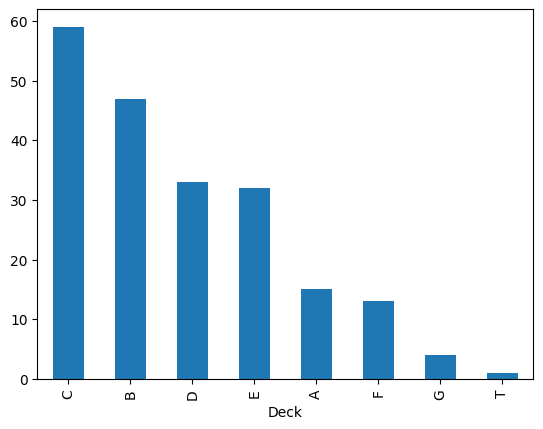

In [11]:
import matplotlib.pyplot as plt
df['Deck'].value_counts().plot(kind='bar')

In [12]:
df['Ticket_number']=df['Ticket'].str.extract(r'(\d+)$')


In [13]:
#After converting ticket number the dtype will be object, so we cant find mean,median,mode etc..., so we have to convert it into numerical data type
df['Ticket_number']=pd.to_numeric(df['Ticket_number'],errors='coerce')

In [14]:
df[['Cabin','Ticket','Deck','Cabin_count','Cabin_Number','Ticket_number']].head(10)

,Cabin,Ticket,Deck,Cabin_count,Cabin_Number,Ticket_number
0,NaN,A/5 21171,NaN,NaN,NaN,21171.0
1,C85,PC 17599,C,1.0,[85],17599.0
2,NaN,STON/O2. 3101282,NaN,NaN,NaN,3101282.0
3,C123,113803,C,1.0,[123],113803.0
4,NaN,373450,NaN,NaN,NaN,373450.0
5,NaN,330877,NaN,NaN,NaN,330877.0
6,E46,17463,E,1.0,[46],17463.0
7,NaN,349909,NaN,NaN,NaN,349909.0
8,NaN,347742,NaN,NaN,NaN,347742.0
9,NaN,237736,NaN,NaN,NaN,237736.0


In [15]:
df['Ticket_prefix']=df['Ticket'].str.replace(r'(\d+)$','',regex=True)

In [16]:
df[['Cabin','Ticket','Deck','Cabin_count','Cabin_Number','Ticket_prefix','Ticket_number']].head(10)

,Cabin,Ticket,Deck,Cabin_count,Cabin_Number,Ticket_prefix,Ticket_number
0,NaN,A/5 21171,NaN,NaN,NaN,A/5,21171.0
1,C85,PC 17599,C,1.0,[85],PC,17599.0
2,NaN,STON/O2. 3101282,NaN,NaN,NaN,STON/O2.,3101282.0
3,C123,113803,C,1.0,[123],,113803.0
4,NaN,373450,NaN,NaN,NaN,,373450.0
5,NaN,330877,NaN,NaN,NaN,,330877.0
6,E46,17463,E,1.0,[46],,17463.0
7,NaN,349909,NaN,NaN,NaN,,349909.0
8,NaN,347742,NaN,NaN,NaN,,347742.0
9,NaN,237736,NaN,NaN,NaN,,237736.0


In [17]:
import numpy as np
df['Ticket_prefix']=df['Ticket_prefix'].replace('',np.nan)

In [18]:
df['Ticket_prefix']=df['Ticket_prefix'].fillna('No_Prefix')
df[['Cabin','Ticket','Deck','Cabin_count','Cabin_Number','Ticket_prefix','Ticket_number']].head(10)

,Cabin,Ticket,Deck,Cabin_count,Cabin_Number,Ticket_prefix,Ticket_number
0,NaN,A/5 21171,NaN,NaN,NaN,A/5,21171.0
1,C85,PC 17599,C,1.0,[85],PC,17599.0
2,NaN,STON/O2. 3101282,NaN,NaN,NaN,STON/O2.,3101282.0
3,C123,113803,C,1.0,[123],No_Prefix,113803.0
4,NaN,373450,NaN,NaN,NaN,No_Prefix,373450.0
5,NaN,330877,NaN,NaN,NaN,No_Prefix,330877.0
6,E46,17463,E,1.0,[46],No_Prefix,17463.0
7,NaN,349909,NaN,NaN,NaN,No_Prefix,349909.0
8,NaN,347742,NaN,NaN,NaN,No_Prefix,347742.0
9,NaN,237736,NaN,NaN,NaN,No_Prefix,237736.0


Handling Date and Time

In [19]:
import numpy as np
import pandas as pd

date=pd.read_csv('orders.csv')
time=pd.read_csv('messages.csv')

In [20]:
date.head(10)

,id,order_date,ship_mode,customer_id,sales
0,100006,2014-09-07,Standard,DK-13375,377.970
1,100090,2014-07-08,Standard,EB-13705,699.192
2,100293,2014-03-14,Standard,NF-18475,91.056
3,100328,2014-01-28,Standard,JC-15340,3.928
4,100363,2014-04-08,Standard,JM-15655,21.376
5,100391,2014-05-25,Standard,BW-11065,14.620
6,100678,2014-04-18,Standard,KM-16720,697.074
7,100706,2014-12-16,Second,LE-16810,129.440
8,100762,2014-11-24,Standard,NG-18355,508.620
9,100860,2014-03-26,Second,CS-12505,18.750


In [21]:
time.head()

,date,msg
0,2013-12-15 00:50:00,ищу на сегодня мужика 37
1,2014-04-29 23:40:00,ПАРЕНЬ БИ ИЩЕТ ДРУГА СЕЙЧАС!! СМС ММС 0955532826
2,2012-12-30 00:21:00,Днепр.м 43 позн.с д/ж *.о 067.16.34.576
3,2014-11-28 00:31:00,КИЕВ ИЩУ Д/Ж ДО 45 МНЕ СЕЙЧАС СКУЧНО 093 629 9...
4,2013-10-26 23:11:00,Зая я тебя никогда не обижу люблю тебя!) Даше


In [22]:
date.info()

<class 'pandas.DataFrame'>
RangeIndex: 5009 entries, 0 to 5008
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           5009 non-null   int64  
 1   order_date   5009 non-null   str    
 2   ship_mode    5009 non-null   str    
 3   customer_id  5009 non-null   str    
 4   sales        5009 non-null   float64
dtypes: float64(1), int64(1), str(3)
memory usage: 195.8 KB


In [23]:
time.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   date    1000 non-null   str  
 1   msg     1000 non-null   str  
dtypes: str(2)
memory usage: 15.8 KB


In [24]:
#COnverting string dtype to datetime dtype
date['order_date']=pd.to_datetime(date['order_date'])
date.info()

<class 'pandas.DataFrame'>
RangeIndex: 5009 entries, 0 to 5008
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           5009 non-null   int64         
 1   order_date   5009 non-null   datetime64[us]
 2   ship_mode    5009 non-null   str           
 3   customer_id  5009 non-null   str           
 4   sales        5009 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(2)
memory usage: 195.8 KB


In [25]:
#Extract year
date['Year']=date['order_date'].dt.year
date.sample(2)

,id,order_date,ship_mode,customer_id,sales,Year
3130,117198,2017-08-31,Standard,BG-11035,659.900,2017
816,100818,2015-05-31,Second,JM-15265,234.516,2015


In [26]:
#Extract Month
date['Month']=date['order_date'].dt.month
date.sample(2)

,id,order_date,ship_mode,customer_id,sales,Year,Month
3630,141747,2017-08-03,Second,SC-20230,16.060,2017,8
3499,134810,2017-05-09,First,MC-17605,272.232,2017,5


In [27]:
#Extract Month
date['Month_Name']=date['order_date'].dt.month_name()
date.sample(2)

,id,order_date,ship_mode,customer_id,sales,Year,Month,Month_Name
4285,139640,2014-11-07,Second,TB-21595,146.688,2014,11,November
668,156790,2014-08-08,Second,VG-21790,155.456,2014,8,August


In [28]:
#Extract day
date['Day_no']=date['order_date'].dt.day
date.sample(2)

,id,order_date,ship_mode,customer_id,sales,Year,Month,Month_Name,Day_no
1288,136798,2015-05-08,Standard,DL-12925,545.91,2015,5,May,8
4199,102715,2014-04-11,Second,JK-15370,737.20,2014,4,April,11


In [29]:
#Extract day
date['Day_Name']=date['order_date'].dt.day_name()
date.sample(2)

,id,order_date,ship_mode,customer_id,sales,Year,Month,Month_Name,Day_no,Day_Name
3062,112956,2017-08-21,Standard,TH-21550,394.480,2017,8,August,21,Monday
3292,124191,2017-06-12,Second,TS-21610,8.856,2017,6,June,12,Monday


In [30]:
date['Is_weekend']=np.where(date['Day_Name'].isin(['Saturday','Sunday']),1,0)
date.head(15)

,id,order_date,ship_mode,customer_id,sales,Year,Month,Month_Name,Day_no,Day_Name,Is_weekend
0,100006,2014-09-07,Standard,DK-13375,377.970,2014,9,September,7,Sunday,1
1,100090,2014-07-08,Standard,EB-13705,699.192,2014,7,July,8,Tuesday,0
2,100293,2014-03-14,Standard,NF-18475,91.056,2014,3,March,14,Friday,0
3,100328,2014-01-28,Standard,JC-15340,3.928,2014,1,January,28,Tuesday,0
4,100363,2014-04-08,Standard,JM-15655,21.376,2014,4,April,8,Tuesday,0
5,100391,2014-05-25,Standard,BW-11065,14.620,2014,5,May,25,Sunday,1
6,100678,2014-04-18,Standard,KM-16720,697.074,2014,4,April,18,Friday,0
7,100706,2014-12-16,Second,LE-16810,129.440,2014,12,December,16,Tuesday,0
8,100762,2014-11-24,Standard,NG-18355,508.620,2014,11,November,24,Monday,0
9,100860,2014-03-26,Second,CS-12505,18.750,2014,3,March,26,Wednesday,0


In [31]:
date['quater']=date['order_date'].dt.quarter
date.head()

,id,order_date,ship_mode,customer_id,sales,Year,Month,Month_Name,Day_no,Day_Name,Is_weekend,quater
0,100006,2014-09-07,Standard,DK-13375,377.970,2014,9,September,7,Sunday,1,3
1,100090,2014-07-08,Standard,EB-13705,699.192,2014,7,July,8,Tuesday,0,3
2,100293,2014-03-14,Standard,NF-18475,91.056,2014,3,March,14,Friday,0,1
3,100328,2014-01-28,Standard,JC-15340,3.928,2014,1,January,28,Tuesday,0,1
4,100363,2014-04-08,Standard,JM-15655,21.376,2014,4,April,8,Tuesday,0,2


In [32]:
date['Semester']=np.where(date['quater'].isin([1,2]),1,2)
date.head()

,id,order_date,ship_mode,customer_id,sales,Year,Month,Month_Name,Day_no,Day_Name,Is_weekend,quater,Semester
0,100006,2014-09-07,Standard,DK-13375,377.970,2014,9,September,7,Sunday,1,3,2
1,100090,2014-07-08,Standard,EB-13705,699.192,2014,7,July,8,Tuesday,0,3,2
2,100293,2014-03-14,Standard,NF-18475,91.056,2014,3,March,14,Friday,0,1,1
3,100328,2014-01-28,Standard,JC-15340,3.928,2014,1,January,28,Tuesday,0,1,1
4,100363,2014-04-08,Standard,JM-15655,21.376,2014,4,April,8,Tuesday,0,2,1


In [33]:
#Todays date
import datetime
today=datetime.datetime.today()
today

datetime.datetime(2026, 7, 22, 18, 27, 28, 532347)

In [34]:
#Everything
today-date['order_date']

0      4336 days 18:27:28.532347
1      4397 days 18:27:28.532347
2      4513 days 18:27:28.532347
3      4558 days 18:27:28.532347
4      4488 days 18:27:28.532347
                  ...           
5004   3183 days 18:27:28.532347
5005   3286 days 18:27:28.532347
5006   3240 days 18:27:28.532347
5007   3250 days 18:27:28.532347
5008   3302 days 18:27:28.532347
Name: order_date, Length: 5009, dtype: timedelta64[us]

In [35]:
#Number of dates passed from day of product purchased
(today-date['order_date']).dt.days

0       4336
1       4397
2       4513
3       4558
4       4488
        ... 
5004    3183
5005    3286
5006    3240
5007    3250
5008    3302
Name: order_date, Length: 5009, dtype: int64

In [36]:
#Number of months passed
np.round((today-date['order_date'])/np.timedelta64(30,'D'),0)

0       145.0
1       147.0
2       150.0
3       152.0
4       150.0
        ...  
5004    106.0
5005    110.0
5006    108.0
5007    108.0
5008    110.0
Name: order_date, Length: 5009, dtype: float64

In [37]:
time.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   date    1000 non-null   str  
 1   msg     1000 non-null   str  
dtypes: str(2)
memory usage: 15.8 KB


In [38]:
time['date']=pd.to_datetime(time['date'])

In [39]:
time.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1000 non-null   datetime64[us]
 1   msg     1000 non-null   str           
dtypes: datetime64[us](1), str(1)
memory usage: 15.8 KB


In [40]:
time.head()

,date,msg
0,2013-12-15 00:50:00,ищу на сегодня мужика 37
1,2014-04-29 23:40:00,ПАРЕНЬ БИ ИЩЕТ ДРУГА СЕЙЧАС!! СМС ММС 0955532826
2,2012-12-30 00:21:00,Днепр.м 43 позн.с д/ж *.о 067.16.34.576
3,2014-11-28 00:31:00,КИЕВ ИЩУ Д/Ж ДО 45 МНЕ СЕЙЧАС СКУЧНО 093 629 9...
4,2013-10-26 23:11:00,Зая я тебя никогда не обижу люблю тебя!) Даше


In [41]:
time['Hour']=time['date'].dt.hour
time['Minute']=time['date'].dt.minute
time['Sec']=time['date'].dt.second

In [42]:
time.head()

,date,msg,Hour,Minute,Sec
0,2013-12-15 00:50:00,ищу на сегодня мужика 37,0,50,0
1,2014-04-29 23:40:00,ПАРЕНЬ БИ ИЩЕТ ДРУГА СЕЙЧАС!! СМС ММС 0955532826,23,40,0
2,2012-12-30 00:21:00,Днепр.м 43 позн.с д/ж *.о 067.16.34.576,0,21,0
3,2014-11-28 00:31:00,КИЕВ ИЩУ Д/Ж ДО 45 МНЕ СЕЙЧАС СКУЧНО 093 629 9...,0,31,0
4,2013-10-26 23:11:00,Зая я тебя никогда не обижу люблю тебя!) Даше,23,11,0


In [43]:
today-time['date']

0     4602 days 17:37:28.532347
1     4466 days 18:47:28.532347
2     4952 days 18:06:28.532347
3     4254 days 17:56:28.532347
4     4651 days 19:16:28.532347
                 ...           
995   5241 days 17:37:28.532347
996   4562 days 19:13:28.532347
997   5027 days 18:50:28.532347
998   5143 days 18:53:28.532347
999   4415 days 19:02:28.532347
Name: date, Length: 1000, dtype: timedelta64[us]

In [44]:
#In seconds
np.round((today-time['date'])/np.timedelta64(1,'s'))

0      397676249.0
1      385930049.0
2      427917989.0
3      367610189.0
4      401915789.0
          ...     
995    452885849.0
996    394226009.0
997    434400629.0
998    444423209.0
999    381524549.0
Name: date, Length: 1000, dtype: float64

In [45]:
#In hour
np.round((today-time['date'])/np.timedelta64(1,'h'))

0      110466.0
1      107203.0
2      118866.0
3      102114.0
4      111643.0
         ...   
995    125802.0
996    109507.0
997    120667.0
998    123451.0
999    105979.0
Name: date, Length: 1000, dtype: float64

Handling Missing Data


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv('datascience.csv')
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [47]:
df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index     479
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
training_hours             766
target                       0
dtype: int64

In [48]:
#Finding how much percent of data is missing.
df.isnull().mean()*100
#there for CCA can apply only on city_development_index,enrolled_university,education_level,experience,training_hours <5% of data is missing                    

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [49]:
df.shape

(19158, 13)

In [50]:
cols=[var for var in df.columns if df[var].isnull().mean()*100 < 5 and df[var].isnull().mean()*100>0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [51]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
8038,0.924,no_enrollment,Graduate,4.0,58.0
7072,0.903,no_enrollment,Masters,20.0,6.0
2295,0.579,Full time course,Graduate,5.0,83.0
6238,0.624,no_enrollment,Masters,6.0,42.0
10868,0.866,no_enrollment,Graduate,20.0,222.0


In [52]:
new_df=df.dropna(subset=cols)

In [53]:
df.head(10)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0
5,21651,city_176,0.764,NaN,Has relevent experience,Part time course,Graduate,STEM,11.0,NaN,NaN,24.0,1.0
6,28806,city_160,0.920,Male,Has relevent experience,no_enrollment,High School,NaN,5.0,50-99,Funded Startup,24.0,0.0
7,402,city_46,0.762,Male,Has relevent experience,no_enrollment,Graduate,STEM,13.0,<10,Pvt Ltd,18.0,1.0
8,27107,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,7.0,50-99,Pvt Ltd,46.0,1.0
9,699,city_103,0.920,NaN,Has relevent experience,no_enrollment,Graduate,STEM,17.0,10000+,Pvt Ltd,123.0,0.0


In [54]:
new_df.head(10)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0
5,21651,city_176,0.764,NaN,Has relevent experience,Part time course,Graduate,STEM,11.0,NaN,NaN,24.0,1.0
6,28806,city_160,0.920,Male,Has relevent experience,no_enrollment,High School,NaN,5.0,50-99,Funded Startup,24.0,0.0
7,402,city_46,0.762,Male,Has relevent experience,no_enrollment,Graduate,STEM,13.0,<10,Pvt Ltd,18.0,1.0
8,27107,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,7.0,50-99,Pvt Ltd,46.0,1.0
9,699,city_103,0.920,NaN,Has relevent experience,no_enrollment,Graduate,STEM,17.0,10000+,Pvt Ltd,123.0,0.0
10,29452,city_21,0.624,NaN,No relevent experience,Full time course,High School,NaN,2.0,NaN,NaN,32.0,1.0


In [55]:
df.shape

(19158, 13)

In [56]:
new_df.shape

(17182, 13)

In [57]:
df['training_hours'].describe()

count    18392.000000
mean        65.185787
std         59.885626
min          1.000000
25%         23.000000
50%         47.000000
75%         88.000000
max        336.000000
Name: training_hours, dtype: float64

In [58]:
new_df['training_hours'].describe()

count    17182.000000
mean        65.055872
std         59.800788
min          1.000000
25%         23.000000
50%         47.000000
75%         88.000000
max        336.000000
Name: training_hours, dtype: float64

In [59]:
df1=df['education_level'].value_counts(normalize=True)

In [60]:
df2=new_df['education_level'].value_counts(normalize=True)

In [61]:
temp=pd.concat([df1,df2],axis=1)
temp.columns=['Original','CCA']
temp

,Original,CCA
education_level,,
Graduate,0.620280,0.619835
Masters,0.233234,0.234082
High School,0.107872,0.107380
Phd,0.022141,0.022116
Primary School,0.016472,0.016587


HANDLING NUMERICAL DATA


In [62]:
import numpy as np
import pandas as pd


df=pd.read_csv('titanic_toy.csv')
df.head(10)

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0
5,NaN,8.4583,0,0
6,54.0,51.8625,0,0
7,2.0,21.0750,4,0
8,27.0,11.1333,2,1
9,14.0,30.0708,1,1


In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [64]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

<Axes: ylabel='Density'>

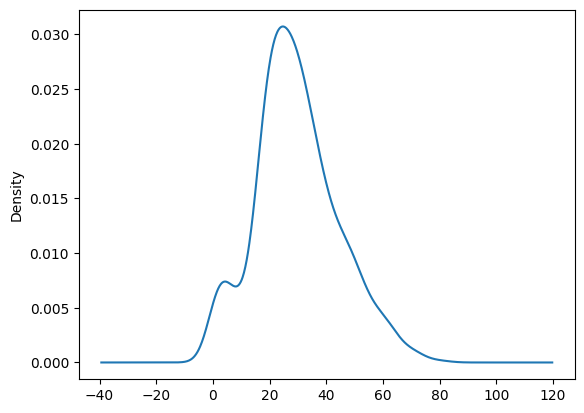

In [65]:
import matplotlib.pyplot as plt
df['Age'].plot(kind='kde')
#KDE plot--> Kernel Density Estimation, smooth version of histogram


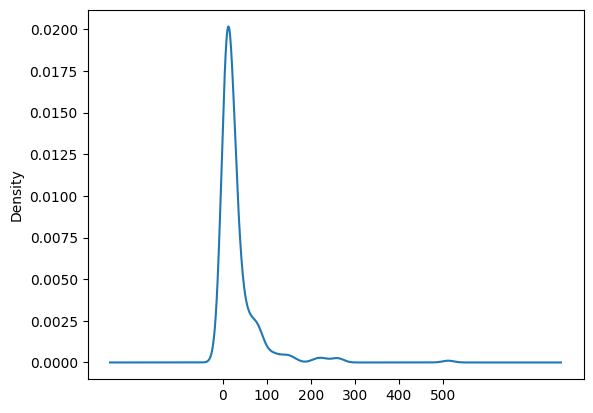

In [66]:
df['Fare'].plot(kind='kde')
plt.xticks([0,100,200,300,400,500])

plt.show()

In [67]:
print(f'Mean: {df["Fare"].mean()}')
print(f'MEdian:{df["Fare"].median()}')
print(f'Skew:{df["Fare"].skew()}')

Mean: 32.279338297872336
MEdian:14.4542
Skew:4.819666600523025


In [68]:
print(f'Mean: {df["Age"].mean()}')
print(f'MEdian:{df["Age"].median()}')
print(f'Skew:{df["Age"].skew()}')

Mean: 29.69911764705882
MEdian:28.0
Skew:0.38910778230082704


In [69]:
df = pd.read_csv('titanic_toy.csv')

In [70]:
median_fare = df['Fare'].median()
df['Fare'] = df['Fare'].fillna(median_fare)

In [71]:
mean_age=df["Age"].mean()
df['Age']=df['Age'].fillna(mean_age)


In [72]:
df.sample(10)

,Age,Fare,Family,Survived
109,29.699118,24.1500,1,1
713,29.000000,9.4833,0,0
801,31.000000,26.2500,2,1
246,25.000000,7.7750,0,0
427,19.000000,26.0000,0,1
479,2.000000,12.2875,1,1
251,29.000000,14.4542,2,0
885,39.000000,29.1250,5,0
280,65.000000,7.7500,0,0
456,65.000000,26.5500,0,0


ARBUTRARY VALUE IMPUTATION

In [73]:
df = pd.read_csv('titanic_toy.csv')

In [74]:
df['Age']=df['Age'].fillna(999)

In [75]:
df.sample(10)

,Age,Fare,Family,Survived
393,23.0,113.2750,1,1
693,25.0,7.2250,0,0
446,13.0,19.5000,1,1
616,34.0,14.4000,2,0
207,26.0,18.7875,0,1
239,33.0,12.2750,0,0
5,999.0,8.4583,0,0
772,57.0,10.5000,0,0
253,30.0,16.1000,1,0
556,48.0,39.6000,1,1


HANDLING CATEGORICAL MISSING DATA

In [76]:
import numpy as np
import pandas as pd

df=pd.read_csv('train.csv')

In [77]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [78]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [79]:
df.isnull().mean()*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [80]:
df['Age'].dtype

dtype('float64')

In [81]:
print(f'Mean:{df["Age"].mean()}')
print(f'Median:{df["Age"].median()}')
print(f'Skew:{df["Age"].skew()}')

Mean:29.69911764705882
Median:28.0
Skew:0.38910778230082704


<Axes: ylabel='Density'>

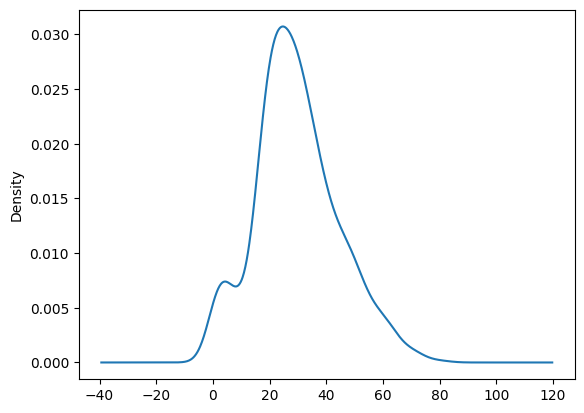

In [82]:
import matplotlib.pyplot as plt
df["Age"].plot(kind='kde')

In [83]:
df['Age']=df['Age'].fillna(df['Age'].mean())

In [84]:
df.isnull().mean()*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age             0.000000
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [85]:
df['Cabin'].dtype

<StringDtype(storage='python', na_value=nan)>

In [86]:
df['Cabin']=df['Cabin'].fillna("MISSING")

In [87]:
df.isnull().mean()*100

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.000000
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.000000
Embarked       0.224467
dtype: float64

In [88]:
df['Embarked'].dtype

<StringDtype(storage='python', na_value=nan)>

In [89]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [90]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,MISSING,C
696,697,0,3,"Kelly, Mr. James",male,44.0,0,0,363592,8.0500,MISSING,S
357,358,0,2,"Funk, Miss. Annie Clemmer",female,38.0,0,0,237671,13.0000,MISSING,S
818,819,0,3,"Holm, Mr. John Fredrik Alexander",male,43.0,0,0,C 7075,6.4500,MISSING,S
167,168,0,3,"Skoog, Mrs. William (Anna Bernhardina Karlsson)",female,45.0,1,4,347088,27.9000,MISSING,S


In [91]:
df['Embarked'].isnull().sum()

np.int64(0)

In [92]:
#Checking wether imputation causes any changes on Distribution
df=pd.read_csv('train.csv')
original_age=df['Age'].copy()

In [93]:
mean_age=df['Age'].mean()
df['Age']=df['Age'].fillna(mean_age)

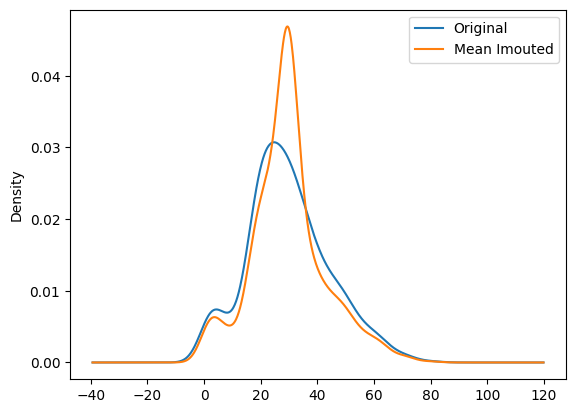

In [94]:
import matplotlib.pyplot as plt

original_age.plot(kind='kde',label='Original')
df['Age'].plot(kind='kde',label='Mean Imouted')
plt.legend()
plt.show()

In [95]:
#Checking wether imputation causes any changes on Mean
df=pd.read_csv('train.csv')


In [96]:
original_age=df['Age'].copy()
mean_age=df['Age'].mean()

df['Age']=df['Age'].fillna(mean_age)

In [97]:
print(f'Original Mean:{original_age.mean()}')
print(f'Imputed Mean:{df["Age"].mean()}')

Original Mean:29.69911764705882
Imputed Mean:29.69911764705882


In [98]:
#Checking wether imputation causes any changes on Variance
df=pd.read_csv('train.csv')

In [99]:
original_age=df['Age'].copy()
mean_age=df['Age'].mean()

df['Age']=df['Age'].fillna(mean_age)

In [100]:
print(f'Original var:{original_age.var()}')
print(f'Imputed var:{df["Age"].var()}')

Original var:211.01912474630802
Imputed var:169.0523999372108


KNN IMPUTER

In [101]:
import pandas as pd

df=pd.read_csv('train.csv')

In [102]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [103]:
df.isnull().mean()*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [104]:
df['Age'].dtype

dtype('float64')

In [105]:
df['Cabin'].dtype

<StringDtype(storage='python', na_value=nan)>

In [106]:
df['Embarked'].dtype

<StringDtype(storage='python', na_value=nan)>

In [107]:
#Select only numerical columns since KNN imputer works only on Numerical columns
num_df=df.select_dtypes(include=['number'])

In [108]:
num_df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


In [109]:
num_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Age            177
SibSp            0
Parch            0
Fare             0
dtype: int64

In [110]:
num_df.isnull().mean()*100

PassengerId     0.00000
Survived        0.00000
Pclass          0.00000
Age            19.86532
SibSp           0.00000
Parch           0.00000
Fare            0.00000
dtype: float64

In [111]:
from sklearn.impute import KNNImputer
#For every missing Age, find 5 most similar passangers and estimate the missing Age using them.
imputer=KNNImputer(n_neighbors=5)

imputed_array=imputer.fit_transform(num_df)#This returns a NumPy Array

num_df=pd.DataFrame(imputed_array,columns=num_df.columns)


In [112]:
num_df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Age            0
SibSp          0
Parch          0
Fare           0
dtype: int64

In [113]:
original_age=df['Age'].copy()

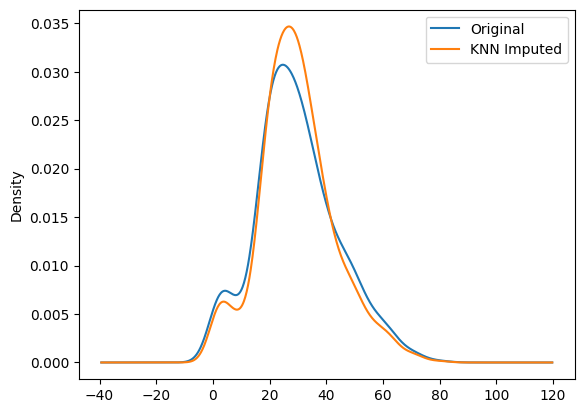

In [114]:
import matplotlib.pyplot as plt

original_age.plot(kind='kde', label='Original')

num_df['Age'].plot(kind='kde', label='KNN Imputed')

plt.legend()
plt.show()

MICE IMPUTATION

In [115]:
import pandas as pd
df=pd.read_csv('train.csv')

In [116]:
original_age=df['Age'].copy()

In [117]:
#Since MICE works on numerical features
num_df=df.select_dtypes(include=['number'])

In [118]:
num_df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


In [119]:
num_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Age            177
SibSp            0
Parch            0
Fare             0
dtype: int64

In [120]:
num_df.isnull().mean()*100

PassengerId     0.00000
Survived        0.00000
Pclass          0.00000
Age            19.86532
SibSp           0.00000
Parch           0.00000
Fare            0.00000
dtype: float64

In [121]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer=IterativeImputer()
imputed_array=imputer.fit_transform(num_df)

num_df=pd.DataFrame(imputed_array,columns=num_df.columns)

In [122]:
num_df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1.0,0.0,3.0,22.0,1.0,0.0,7.2500
1,2.0,1.0,1.0,38.0,1.0,0.0,71.2833
2,3.0,1.0,3.0,26.0,0.0,0.0,7.9250
3,4.0,1.0,1.0,35.0,1.0,0.0,53.1000
4,5.0,0.0,3.0,35.0,0.0,0.0,8.0500


In [123]:
num_df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Age            0
SibSp          0
Parch          0
Fare           0
dtype: int64

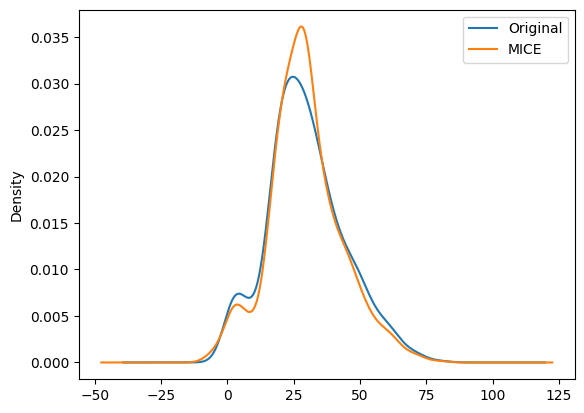

In [126]:
import matplotlib.pyplot as plt
original_age.plot(kind='kde',label='Original')
num_df['Age'].plot(kind='kde',label='MICE')

plt.legend()
plt.show()

In [127]:
print(f'Mean:{original_age.mean()}')
print(f'MEan:{num_df["Age"].mean()}')

Mean:29.69911764705882
MEan:29.315821703563856


In [128]:
print(original_age.var())
print(num_df['Age'].var())

211.01912474630802
187.52507276893084
